# A. Praktikum

In [ ]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
  try:
    mod = __import__(nama)
    print(f"{nama} : {mod.__version__}")
  except ImportError:
    print(f"{nama} : BELUM TERPASANG")

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.35
CPU core: 2
pandas : 2.2.3
numpy : 2.1.3
pyarrow : 18.1.0
matplotlib : 3.10.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/data"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
[]


In [ ]:
import time, os, psutil
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
  return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
  """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
  m0, t0 = rss_mb(), time.perf_counter()
  hasil = fungsi()
  detik = time.perf_counter() - t0
  delta = rss_mb() - m0
  catatan.append({"langkah": label, "detik": round(detik, 2),
                  "delta_rss_mb": round(delta, 1)})
  print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
  return hasil

In [ ]:
import urllib.request

URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
        "yellow_tripdata_2021-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2021-01.parquet")

if not os.path.exists(PATH):
  ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

[unduh dataset] 0.51 s | RSS +1.4 MB
Ukuran file: 20.7 MB


In [ ]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

Jumlah baris : 1,369,769
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [ ]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh                                # bebaskan memori sebelum percobaan kedua
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 0.84 s | RSS +416.0 MB
Dimensi: (1369769, 19)
Memori : 251.0 MB
[baca kolom terpilih] 0.22 s | RSS +78.2 MB
Dimensi: (1369769, 8)
Memori : 83.6 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2021-01-01 00:30:10,2021-01-01 00:36:12,1.0,2.10,2,8.0,0.00,11.80
1,2021-01-01 00:51:20,2021-01-01 00:52:19,1.0,0.20,2,3.0,0.00,4.30
2,2021-01-01 00:43:30,2021-01-01 01:11:06,1.0,14.70,1,42.0,8.65,51.95
3,2021-01-01 00:15:48,2021-01-01 00:31:01,0.0,10.60,1,29.0,6.05,36.35
4,2021-01-01 00:31:49,2021-01-01 00:48:21,1.0,4.94,1,16.5,4.06,24.36


In [ ]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1369769 entries, 0 to 1369768
Data columns (total 8 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   tpep_pickup_datetime   1369769 non-null  datetime64[us]
 1   tpep_dropoff_datetime  1369769 non-null  datetime64[us]
 2   passenger_count        1271417 non-null  float64       
 3   trip_distance          1369769 non-null  float64       
 4   payment_type           1369769 non-null  int64         
 5   fare_amount            1369769 non-null  float64       
 6   tip_amount             1369769 non-null  float64       
 7   total_amount           1369769 non-null  float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 83.6 MB


,0
tpep_pickup_datetime,10.450508
payment_type,10.450508
tpep_dropoff_datetime,10.450508
passenger_count,10.450508
trip_distance,10.450508
tip_amount,10.450508
fare_amount,10.450508
total_amount,10.450508
Index,0.000126


In [ ]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
  df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

83.6 MB -> 53.6 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


In [ ]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"           : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"          : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit"   : (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0"    : (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   1.369769e+06  1.369769e+06  1.369769e+06
mean    4.631983e+00  1.391168e+01  1.747441e+01
std     3.939037e+02  1.312006e+02  1.467865e+01
min     0.000000e+00 -1.350846e+05 -4.928000e+02
25%     1.000000e+00  5.566667e+00  1.080000e+01
50%     1.700000e+00  9.066667e+00  1.380000e+01
75%     3.020000e+00  1.461667e+01  1.912000e+01
max     2.631633e+05  2.881770e+04  7.661280e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          98352
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 19,952 baris (1.46%)
durasi <= 0           : 6,557 baris (0.48%)
durasi > 180 menit    : 2,506 baris (0.18%)
total_amount <= 0     : 7,114 baris (0.52%)


In [ ]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

1,369,769 baris -> 1,329,559 baris (dibuang 40,210)


In [ ]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

[tulis CSV] 15.78 s | RSS +5.5 MB
Parquet: 20.7 MB
CSV    : 99.5 MB


In [ ]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 1.87 s | RSS +11.6 MB
1,329,559 baris | rata-rata total_amount = 17.49


In [ ]:
!pip install -q pyspark==3.5.1
!java -version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 16.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[0.018s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.019s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.11" 2026-04-21
OpenJDK Runtime Environment (build 21.0.11+10-1-22.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.11+10-1-22.04.2-Ubuntu, mixed mode, sharin

In [ ]:
from pyspark.sql import SparkSession, functions as F

# Membuat sesi Spark lokal
spark = (SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")                  # menggunakan semua core mesin ini
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [ ]:
# Memuat data dan inspeksi awal
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

# Pembersihan data (veracity) - dengan perbaikan cast timestamp
sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.col("tpep_dropoff_datetime").cast("timestamp").cast("long")
        - F.col("tpep_pickup_datetime").cast("timestamp").cast("long")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

# Agregasi data per jam
hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 2.51 s | RSS +0.0 MB
Jumlah baris: 1369769
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

In [ ]:
# Kueri Spark SQL
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                    AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()    # rencana eksekusi — perhatikan Exchange / HashAggregate
spark.stop()             # bebaskan sumber daya sebelum lanjut

+------------+------+----------+--------+
|payment_type|jumlah|rata_tarif|rata_tip|
+------------+------+----------+--------+
|           1|918072|     17.14|    2.65|
|           2|314196|      14.5|     0.0|
|           0| 90600|     31.51|    1.76|
|           3|  4838|      16.5|     0.0|
|           4|  1853|     15.92|     0.0|
+------------+------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#84 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#84 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=206]
      +- HashAggregate(keys=[jam#84], functions=[count(1), avg(trip_distance#4), avg(total_amount#16)])
         +- Exchange hashpartitioning(jam#84, 8), ENSURE_REQUIREMENTS, [plan_id=203]
            +- HashAggregate(keys=[jam#84], functions=[partial_count(1), partial_avg(trip_distance#4), partial_avg(total_amount#16)])
               +- Project [trip_distance#4, total_amount#16, hour(tpep_pickup_datetime#1, Some(Etc/UTC))

In [ ]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,11617,4.57,12.13,21.340000,15.80
1,1,7528,4.28,12.10,20.410000,15.95
2,2,4225,4.12,11.85,19.950001,15.00
3,3,2527,4.18,12.44,20.450001,15.30
4,4,2921,5.01,12.82,23.209999,17.16
5,5,7735,5.31,13.09,24.080000,16.00
6,6,23937,3.65,11.10,18.520000,12.95
7,7,44677,2.97,11.10,16.990000,13.30
8,8,67545,2.60,11.27,16.360001,13.55
9,9,72948,2.59,11.27,16.410000,13.55


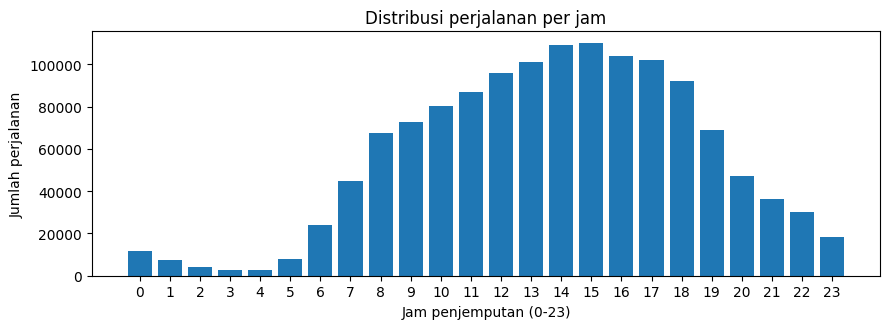

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

# B. Studi Kasus

Kasus: penjadwalan armada oleh operator taksi
Sebuah operator memiliki 1.200 armada dan ingin menyusun jadwal shift pengemudi untuk kuartal berikutnya. Manajemen operasional meminta jawaban atas tiga pertanyaan: (1) pada jam berapa permintaan tertinggi dan terendah; (2) apakah pola tersebut berbeda antara hari kerja dan akhir pekan; (3) apakah perjalanan pada jam sibuk lebih pendek namun lebih menguntungkan per menit dibanding jam lain. Tim data Anda hanya diberi waktu satu hari kerja dan satu mesin — tanpa klaster.

--- 12 Baris Pertama Tabel Agregasi ---


,akhir_pekan,jam,jumlah,rata_durasi,rata_tarif_per_menit
0,False,0,6523,12.49,2.07
1,False,1,4124,12.37,2.04
2,False,2,2453,12.14,2.03
3,False,3,1507,12.76,2.00
4,False,4,2083,12.55,2.23
5,False,5,6241,12.84,2.11
6,False,6,20309,11.03,1.96
7,False,7,38839,11.18,1.80
8,False,8,59267,11.43,1.69
9,False,9,60222,11.62,1.66


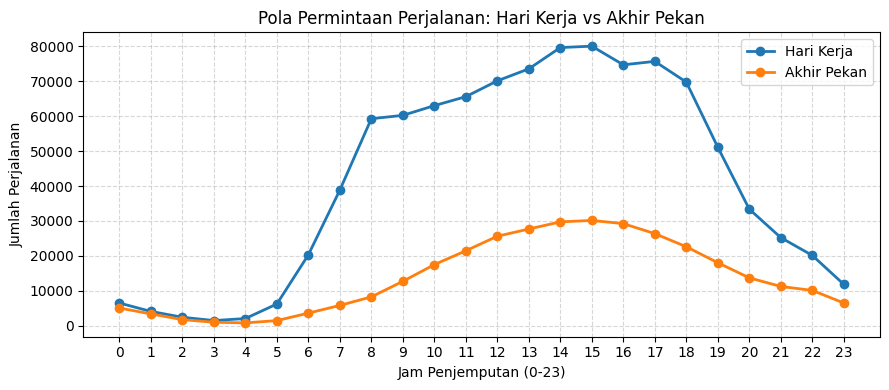

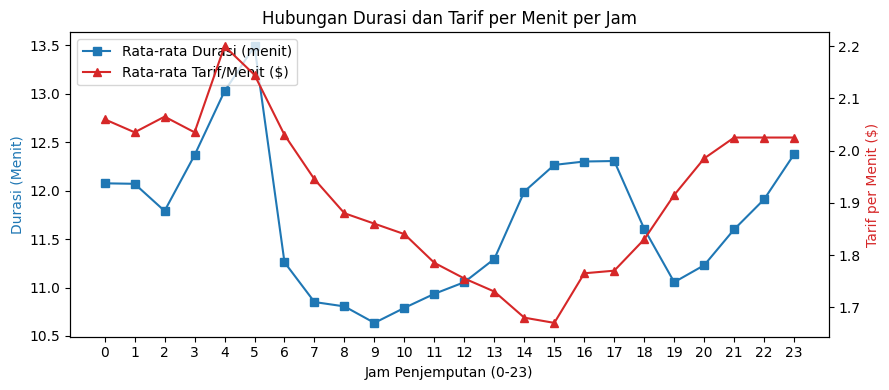

In [ ]:
import matplotlib.pyplot as plt

# 1. Feature Engineering (Menambahkan Dimensi Baru)
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

# 2. Agregasi Data per Hari Kerja vs Akhir Pekan dan Jam
ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .reset_index())

print("--- 12 Baris Pertama Tabel Agregasi ---")
display(ringkas.head(12))

# 3. Grafik 1: Distribusi Permintaan Perjalanan (Hari Kerja vs Akhir Pekan)
plt.figure(figsize=(9, 4))
for is_weekend, df_group in ringkas.groupby("akhir_pekan"):
    label = "Akhir Pekan" if is_weekend else "Hari Kerja"
    plt.plot(df_group["jam"], df_group["jumlah"], marker='o', linewidth=2, label=label)

plt.xlabel("Jam Penjemputan (0-23)")
plt.ylabel("Jumlah Perjalanan")
plt.title("Pola Permintaan Perjalanan: Hari Kerja vs Akhir Pekan")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/studi_kasus_permintaan.png", dpi=150)
plt.show()

# 4. Grafik 2: Profil Profitabilitas (Tarif per Menit) dan Durasi Perjalanan per Jam
ringkas_jam = ringkas.groupby("jam").agg(
    rata_durasi=("rata_durasi", "mean"),
    rata_tarif_per_menit=("rata_tarif_per_menit", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

line1 = ax1.plot(ringkas_jam["jam"], ringkas_jam["rata_durasi"], color='tab:blue', marker='s', label='Rata-rata Durasi (menit)')
line2 = ax2.plot(ringkas_jam["jam"], ringkas_jam["rata_tarif_per_menit"], color='tab:red', marker='^', label='Rata-rata Tarif/Menit ($)')

ax1.set_xlabel("Jam Penjemputan (0-23)")
ax1.set_ylabel("Durasi (Menit)", color='tab:blue')
ax2.set_ylabel("Tarif per Menit ($)", color='tab:red')
plt.title("Hubungan Durasi dan Tarif per Menit per Jam")
ax1.set_xticks(range(0, 24))

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/studi_kasus_profitabilitas.png", dpi=150)
plt.show()

# C. Latihan

1. Latihan 1: Hitung 5 nilai trip_distance terbesar pada data bersih dan tampilkan baris lengkapnya. Apakah baris-baris itu masuk akal? Beri komentar satu kalimat.

In [ ]:
top5_jarak = bersih.nlargest(5, "trip_distance")
display(top5_jarak)

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
809527,2021-01-21 11:46:25,2021-01-21 13:28:41,1.0,95.50,4,0.010000,0.000000,6.430000,102.266667,11,Thursday,False,0.063
860973,2021-01-22 11:15:28,2021-01-22 12:58:00,1.0,93.47,1,200.000000,43.009998,258.059998,102.533333,11,Friday,False,2.517
1325583,2021-01-18 10:06:00,2021-01-18 10:45:00,NaN,92.23,0,43.200001,0.000000,46.500000,39.000000,10,Monday,False,1.192
433901,2021-01-12 14:41:52,2021-01-12 16:31:59,3.0,90.44,2,93.879997,0.000000,100.300003,110.116667,14,Tuesday,False,0.911
1323037,2021-01-17 00:19:00,2021-01-17 00:48:00,NaN,90.32,0,63.830002,2.750000,73.500000,29.000000,0,Sunday,True,2.534


2. Latihan 2: Ulangi J-7 dengan chunksize=100_000 lalu chunksize=1_000_000. Catat waktu dan delta_rss_mb keduanya, dan jelaskan arah trade-off-nya.


In [ ]:
print("--- Chunksize = 100,000 ---")
ukur("chunking 100k", lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000))

print("\n--- Chunksize = 1,000,000 ---")
ukur("chunking 1M", lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000))

--- Chunksize = 100,000 ---
[chunking 100k] 2.28 s | RSS +4.9 MB

--- Chunksize = 1,000,000 ---
[chunking 1M] 3.04 s | RSS +8.1 MB


(1329559,
 np.float64(23258121.0),
 {0: (11617, np.float64(247853.64)),
  1: (7528, np.float64(153660.94)),
  2: (4225, np.float64(84295.08000000002)),
  3: (2527, np.float64(51680.380000000005)),
  4: (2921, np.float64(67803.45000000001)),
  5: (7735, np.float64(186270.38)),
  6: (23937, np.float64(443227.1100000001)),
  7: (44677, np.float64(758871.4600000001)),
  8: (67545, np.float64(1105126.2200000002)),
  9: (72948, np.float64(1197084.99)),
  10: (80519, np.float64(1339799.5700000003)),
  11: (87052, np.float64(1430095.9200000004)),
  12: (95737, np.float64(1564548.3800000001)),
  13: (101226, np.float64(1662009.3300000003)),
  14: (109374, np.float64(1851476.1400000001)),
  15: (110175, np.float64(1879514.85)),
  16: (103928, np.float64(1868561.9100000001)),
  17: (102056, np.float64(1850718.6099999999)),
  18: (92368, np.float64(1641413.4500000004)),
  19: (69158, np.float64(1237412.48)),
  20: (47107, np.float64(883735.29)),
  21: (36508, np.float64(730852.9900000001)),
  22: 

3. Latihan 3: Buat kolom persen_tip = tip_amount / fare_amount * 100, tangani kasus fare_amount == 0 dengan benar, lalu hitung rata-rata persen tip per payment_type. Apa dugaan Anda tentang perbedaan antar metode pembayaran?


In [ ]:
import numpy as np

bersih["persen_tip"] = np.where(
    bersih["fare_amount"] > 0,
    (bersih["tip_amount"] / bersih["fare_amount"]) * 100,
    0.0
)

rata_tip = bersih.groupby("payment_type")["persen_tip"].mean().round(2).reset_index()
display(rata_tip)

/tmp/ipykernel_2407/4157987808.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rata_tip = bersih.groupby("payment_type")["persen_tip"].mean().round(2).reset_index()


,payment_type,persen_tip
0,0,9.80
1,1,27.67
2,2,0.00
3,3,0.01
4,4,0.00


4. Latihan 4: Simpan bersih sebagai Parquet dengan dua kompresi berbeda
(compression="snappy" dan "gzip"). Bandingkan ukuran file dan waktu tulisnya.

In [ ]:
PATH_SNAPPY = os.path.join(DIR_KERJA, "trips_snappy.parquet")
PATH_GZIP   = os.path.join(DIR_KERJA, "trips_gzip.parquet")

ukur("tulis Parquet Snappy", lambda: bersih.to_parquet(PATH_SNAPPY, compression="snappy", index=False))
ukur("tulis Parquet Gzip",   lambda: bersih.to_parquet(PATH_GZIP,   compression="gzip",   index=False))

size_snappy = round(os.path.getsize(PATH_SNAPPY) / 1024**2, 2)
size_gzip   = round(os.path.getsize(PATH_GZIP) / 1024**2, 2)

print(f"Ukuran File Snappy : {size_snappy} MB")
print(f"Ukuran File Gzip   : {size_gzip} MB")

[tulis Parquet Snappy] 0.93 s | RSS +57.4 MB
[tulis Parquet Gzip] 4.49 s | RSS +0.1 MB
Ukuran File Snappy : 29.17 MB
Ukuran File Gzip   : 23.29 MB


5.  Latihan 5: Tulis ulang agregasi per jam J-9 memakai Spark SQL, lalu buktikan bahwa hasil keduanya konsisten dengan membandingkan kolom jumlah secara terprogram (mis. selisih maksimum = 0). Jika ada selisih, jelaskan sumbernya.

In [ ]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
    .appName("Latihan5")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())

# Membaca file parquet bersih langsung dari pandas/parquet
sdf_lat5 = spark.createDataFrame(bersih)
sdf_lat5.createOrReplaceTempView("trips_bersih")

# Agregasi jam menggunakan Spark SQL
agregasi_spark_sql = spark.sql("""
    SELECT jam, COUNT(*) AS jumlah_perjalanan
    FROM trips_bersih
    GROUP BY jam
    ORDER BY jam
""").toPandas()

# Verifikasi konsistensi selisih maksimum
selisih_maks = (agregasi["jumlah_perjalanan"] - agregasi_spark_sql["jumlah_perjalanan"]).abs().max()
print("Selisih maksimum jumlah perjalanan (pandas vs Spark SQL):", selisih_maks)

spark.stop()

Selisih maksimum jumlah perjalanan (pandas vs Spark SQL): 0
